# IT2011 – Breast Cancer Wisconsin (Original)

## Member 04 – Feature Scaling

### Main Focus
- Feature Scaling
- Standardization using StandardScaler
- Before vs After Scaling Analysis

### Dataset
UCI Breast Cancer Wisconsin (Original)

In [15]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [18]:
# ============================================
# STEP 2 - Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


In [21]:
# ============================================
# STEP 3 - Load the raw dataset
# ============================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
df = pd.read_csv(url, header=None)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (699, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [22]:
# ============================================
# STEP 4 - Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

df.head()

,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [23]:
# ============================================
# STEP 5 - Check the dataset structure
# ============================================

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing value markers:")
print((df == "?").sum())

Dataset shape: (699, 11)

Data types:
Sample_ID                      int64
Clump_Thickness                int64
Uniformity_Cell_Size           int64
Uniformity_Cell_Shape          int64
Marginal_Adhesion              int64
Single_Epithelial_Cell_Size    int64
Bare_Nuclei                      str
Bland_Chromatin                int64
Normal_Nucleoli                int64
Mitoses                        int64
Class                          int64
dtype: object

Missing value markers:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [24]:
# ============================================
# STEP 6 - Replace '?' with NaN
# ============================================

df = df.replace("?", np.nan)

print("Missing values after replacing '?':")
print(df.isnull().sum())

Missing values after replacing '?':
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [25]:
# ============================================
# STEP 7 - Convert Bare_Nuclei to numeric
# ============================================

df["Bare_Nuclei"] = pd.to_numeric(
    df["Bare_Nuclei"],
    errors="coerce"
)

print(df.dtypes)

Sample_ID                        int64
Clump_Thickness                  int64
Uniformity_Cell_Size             int64
Uniformity_Cell_Shape            int64
Marginal_Adhesion                int64
Single_Epithelial_Cell_Size      int64
Bare_Nuclei                    float64
Bland_Chromatin                  int64
Normal_Nucleoli                  int64
Mitoses                          int64
Class                            int64
dtype: object


In [26]:
# ============================================
# STEP 8 - Define the predictor features
# ============================================

feature_columns = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

X = df[feature_columns].copy()

print("Number of features:", len(feature_columns))
print("Feature matrix shape:", X.shape)

X.head()

Number of features: 9
Feature matrix shape: (699, 9)


,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


In [27]:
# ============================================
# STEP 9 - Encode the target variable
# ============================================

y = df["Class"].map({
    2: 0,   # Benign
    4: 1    # Malignant
})

print("Encoded target values:")
print(y.value_counts().sort_index())

Encoded target values:
Class
0    458
1    241
Name: count, dtype: int64


In [28]:
# ============================================
# STEP 10 - Check feature ranges before scaling
# ============================================

before_scaling = X.describe().T[
    ["min", "max", "mean", "std"]
]

before_scaling

,min,max,mean,std
Clump_Thickness,1.0,10.0,4.417740,2.815741
Uniformity_Cell_Size,1.0,10.0,3.134478,3.051459
Uniformity_Cell_Shape,1.0,10.0,3.207439,2.971913
Marginal_Adhesion,1.0,10.0,2.806867,2.855379
Single_Epithelial_Cell_Size,1.0,10.0,3.216023,2.214300
Bare_Nuclei,1.0,10.0,3.544656,3.643857
Bland_Chromatin,1.0,10.0,3.437768,2.438364
Normal_Nucleoli,1.0,10.0,2.866953,3.053634
Mitoses,1.0,10.0,1.589413,1.715078


## Why Feature Scaling?

Feature scaling puts numerical features onto a common scale.

In this project, StandardScaler is used because:

- Logistic Regression can be affected by feature scale.
- SVM is sensitive to feature scale because it uses distances/margins.
- PCA is strongly affected by feature variance.
- Standardization allows the features to contribute on a comparable scale.

StandardScaler transforms each feature so that:

- Mean ≈ 0
- Standard deviation ≈ 1

The transformation is:

z = (x - mean) / standard deviation

The scaling parameters should be learned from the training data when building the final ML model to avoid data leakage.

In [29]:
# ============================================
# STEP 12 - Apply StandardScaler
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Scaling completed.
Scaled data shape: (699, 9)


In [30]:
# ============================================
# STEP 13 - Create a DataFrame for scaled data
# ============================================

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_columns,
    index=X.index
)

X_scaled_df.head()

,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
0,0.206936,-0.699995,-0.743299,-0.633247,-0.549561,-0.698853,-0.179662,-0.611825,-0.343912
1,0.206936,0.283845,0.266875,0.768621,1.710106,1.772867,-0.179662,-0.284112,-0.343912
2,-0.503866,-0.699995,-0.743299,-0.633247,-0.549561,-0.424217,-0.179662,-0.611825,-0.343912
3,0.562336,1.595632,1.613773,-0.633247,-0.097628,0.125054,-0.179662,1.354454,-0.343912
4,-0.148465,-0.699995,-0.743299,0.067687,-0.549561,-0.698853,-0.179662,-0.611825,-0.343912


In [31]:
# ============================================
# STEP 14 - Check feature statistics after scaling
# ============================================

after_scaling = X_scaled_df.describe().T[
    ["min", "max", "mean", "std"]
]

after_scaling

,min,max,mean,std
Clump_Thickness,-1.214667,1.983939,-5.082566e-17,1.000716
Uniformity_Cell_Size,-0.699995,2.251526,-9.148619e-17,1.000716
Uniformity_Cell_Shape,-0.743299,2.287222,-3.049540e-17,1.000716
Marginal_Adhesion,-0.633247,2.520955,5.082566e-17,1.000716
Single_Epithelial_Cell_Size,-1.001495,3.065906,5.082566e-17,1.000716
Bare_Nuclei,-0.698853,1.772867,0.000000e+00,1.000733
Bland_Chromatin,-1.000471,2.693171,3.049540e-17,1.000716
Normal_Nucleoli,-0.611825,2.337594,-1.321467e-16,1.000716
Mitoses,-0.343912,4.907421,-8.132106e-17,1.000716


In [32]:
# ============================================
# STEP 15 - Compare before and after scaling
# ============================================

comparison = pd.DataFrame({
    "Before_Mean": X.mean(),
    "Before_Std": X.std(),
    "After_Mean": X_scaled_df.mean(),
    "After_Std": X_scaled_df.std()
})

comparison

,Before_Mean,Before_Std,After_Mean,After_Std
Clump_Thickness,4.417740,2.815741,-5.082566e-17,1.000716
Uniformity_Cell_Size,3.134478,3.051459,-9.148619e-17,1.000716
Uniformity_Cell_Shape,3.207439,2.971913,-3.049540e-17,1.000716
Marginal_Adhesion,2.806867,2.855379,5.082566e-17,1.000716
Single_Epithelial_Cell_Size,3.216023,2.214300,5.082566e-17,1.000716
Bare_Nuclei,3.544656,3.643857,0.000000e+00,1.000733
Bland_Chromatin,3.437768,2.438364,3.049540e-17,1.000716
Normal_Nucleoli,2.866953,3.053634,-1.321467e-16,1.000716
Mitoses,1.589413,1.715078,-8.132106e-17,1.000716


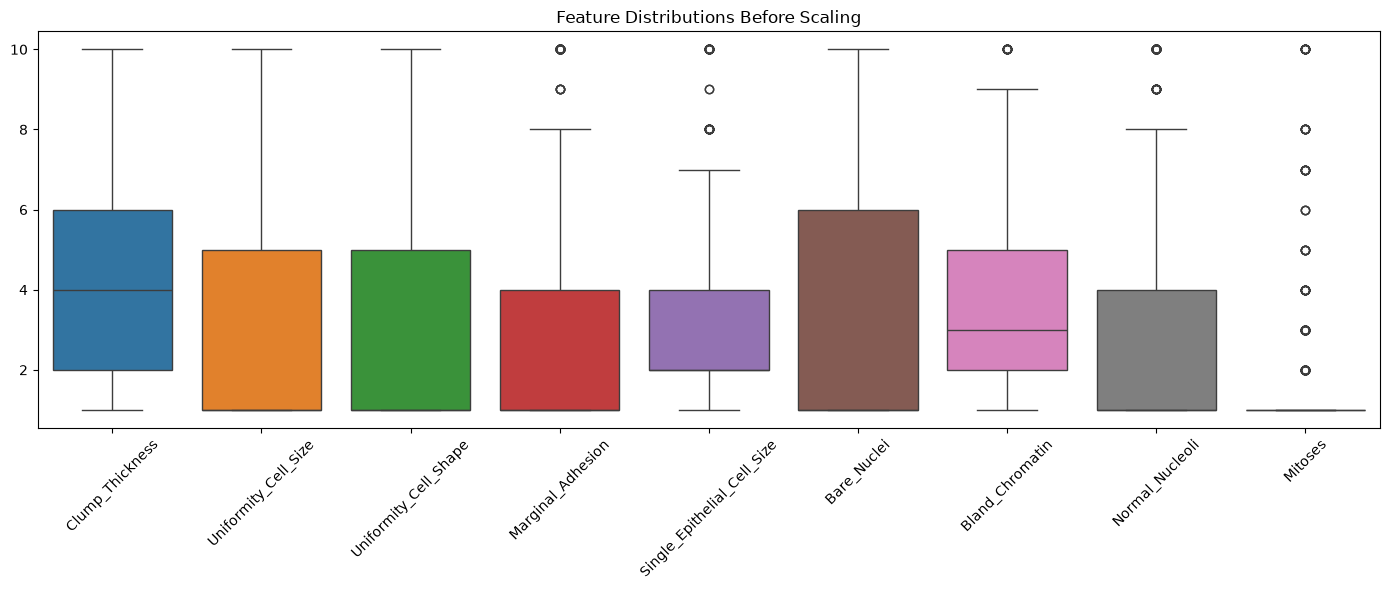

In [33]:
# ============================================
# STEP 16 - Visualize feature distributions before scaling
# ============================================

plt.figure(figsize=(14, 6))

sns.boxplot(data=X)

plt.title("Feature Distributions Before Scaling")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

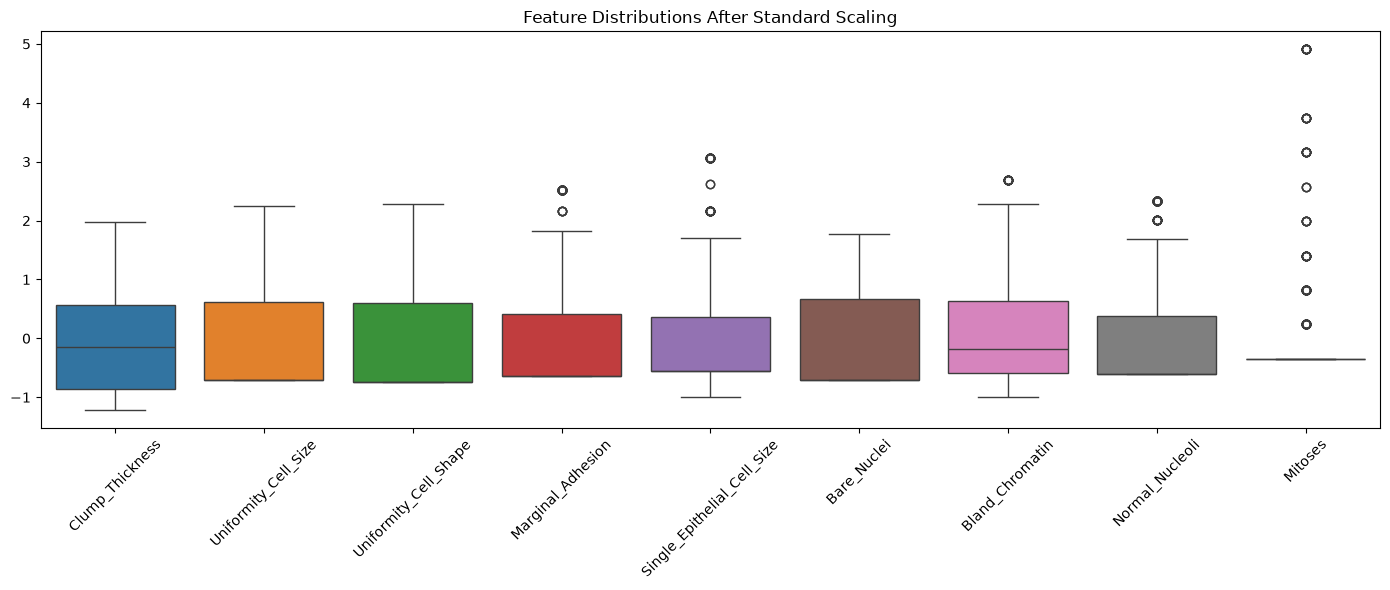

In [34]:
# ============================================
# STEP 17 - Visualize feature distributions after scaling
# ============================================

plt.figure(figsize=(14, 6))

sns.boxplot(data=X_scaled_df)

plt.title("Feature Distributions After Standard Scaling")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [35]:
# ============================================
# STEP 18 - Check missing values before final modeling
# ============================================

print("Missing values in feature matrix:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values in feature matrix:
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
dtype: int64

Total missing values: 16


## Important Note About Missing Values

StandardScaler cannot directly calculate scaling values for missing entries.

The original dataset contains 16 missing values in the Bare_Nuclei feature.

For the final machine learning models, missing-value imputation is handled before scaling inside a Pipeline.

This is important because the imputer and scaler should be fitted using the training data only.

This prevents data leakage during model evaluation and cross-validation.

In [36]:
# ============================================
# STEP 20 - Save scaled features
# ============================================

output_path = "results/outputs/scaled_features.csv"

X_scaled_df.to_csv(output_path, index=False)

print("Scaled features saved to:")
print(output_path)

Scaled features saved to:
results/outputs/scaled_features.csv


In [37]:
# ============================================
# STEP 21 - Save before and after scaling comparison
# ============================================

comparison_path = "results/outputs/scaling_comparison.csv"

comparison.to_csv(comparison_path)

print("Scaling comparison saved to:")
print(comparison_path)

Scaling comparison saved to:
results/outputs/scaling_comparison.csv


# Feature Scaling Summary

## What Was Done?

1. Loaded the original Breast Cancer Wisconsin dataset.
2. Replaced `?` with NaN.
3. Converted `Bare_Nuclei` to numeric.
4. Selected the 9 predictive features.
5. Encoded the target:
   - 2 = Benign → 0
   - 4 = Malignant → 1
6. Examined the feature statistics before scaling.
7. Applied StandardScaler.
8. Compared feature statistics before and after scaling.
9. Visualized the distributions before and after scaling.
10. Saved the scaled feature data and comparison results.

## Main Finding

StandardScaler transformed the numerical features to a common standardized scale, with means approximately equal to 0 and standard deviations approximately equal to 1.

## Why Is This Useful?

Scaling is important for:

- Logistic Regression
- Support Vector Machine (SVM)
- Principal Component Analysis (PCA)

## Important Modeling Note

For final machine learning evaluation, imputation and scaling should be performed inside a Pipeline and fitted only on the training data. This prevents data leakage.